# Guided Lab: Multi-Agent Supervisor Graph

This notebook builds a practical multi-agent system for a public-policy research brief.

Use case:
- Researcher agent pulls evidence from a real PDF
- Writer agent drafts an executive brief
- QA agent checks the draft for unsupported claims and clarity
- Supervisor node coordinates the workflow

LangChain’s multi-agent docs say a main agent coordinates subagents as tools, and that subagents are useful when you need centralized control, parallelization, or specialized knowledge. The component-architecture page also lists multi-agent systems as a core LangChain pattern. 


## Why this use case

A public-policy brief is a good fit for a multi-agent graph because the work naturally splits into specialized steps:

- research evidence from the document
- draft a readable brief
- verify that the brief stays grounded in the source

This matches the subagent pattern where the main orchestrator maintains the conversation while subagents stay specialized. 


## 1) Install packages


In [1]:
%pip install -qU \
    python-dotenv requests pypdf \
    langchain langchain-core langchain-groq \
    langchain-chroma chromadb sentence-transformers \
    langgraph langgraph-checkpoint-memory


Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python <3.13,>=3.8.1; 0.1.0rc1 Requires-Python <3.13,>=3.8.1; 0.1.1 Requires-Python <3.13,>=3.8.1
ERROR: Could not find a version that satisfies the requirement langgraph-checkpoint-memory (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for langgraph-checkpoint-memory


## 2) Load environment variables

Create a `.env` file with:

```env
GROQ_API_KEY=your_groq_api_key
LANGSMITH_API_KEY=your_langsmith_api_key
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=multi_agent_supervisor_graph
```


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.getenv('GROQ_API_KEY')
LANGSMITH_API_KEY = os.getenv('LANGSMITH_API_KEY')
LANGSMITH_TRACING = os.getenv('LANGSMITH_TRACING', 'true').lower() == 'true'
LANGSMITH_PROJECT = os.getenv('LANGSMITH_PROJECT', 'multi_agent_supervisor_graph')

print('GROQ_API_KEY set:', bool(GROQ_API_KEY))
print('LANGSMITH_API_KEY set:', bool(LANGSMITH_API_KEY))
print('LANGSMITH_TRACING:', LANGSMITH_TRACING)
print('LANGSMITH_PROJECT:', LANGSMITH_PROJECT)


GROQ_API_KEY set: True
LANGSMITH_API_KEY set: True
LANGSMITH_TRACING: True
LANGSMITH_PROJECT: lcel-groq-demo


## 3) Download a real PDF

We will use a public-policy paper that discusses explainability in policy decisions. The paper’s abstract and topic fit a research-to-brief workflow well. 


In [3]:
from pathlib import Path
import requests

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

PDF_URL = 'https://www.arxiv.org/pdf/2010.14374.pdf'
PDF_PATH = DATA_DIR / 'public_policy_explainability.pdf'

def download_file(url: str, dest: Path) -> Path:
    if dest.exists() and dest.stat().st_size > 0:
        print('Using cached file:', dest)
        return dest
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    dest.write_bytes(resp.content)
    print('Downloaded:', dest)
    return dest

download_file(PDF_URL, PDF_PATH)


Using cached file: data\public_policy_explainability.pdf


WindowsPath('data/public_policy_explainability.pdf')

## 4) Load and chunk the PDF

LangChain’s knowledge-base flow is load → split → embed → store. We use that pattern here for the researcher agent. 


In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = PyPDFLoader(str(PDF_PATH))
pages = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
)

chunks = splitter.split_documents(pages)

print('Pages:', len(pages))
print('Chunks:', len(chunks))
print('First page preview:')
print(pages[0].page_content[:500])


C:\Users\MadhiarasanM\AppData\Local\Temp\ipykernel_20704\3591481574.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
C:\Users\MadhiarasanM\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pages: 21
Chunks: 124
First page preview:
arXiv:2010.14374v3  [cs.LG]  16 Feb 2023
Explainable Machine Learning for Public Policy: Use Cases, Gaps,
and Research Directions
Kasun Amarasinghe, Kit T. Rodolfa, Hemank Lamba, and Rayid G hani
Machine Learning Department and Heinz College of Informati on Systems and Public Policy,
Carnegie Mellon University
Abstract
Explainability is highly-desired in Machine Learning (ML) systems supporting high-stakes policy decisions in
areas such as health, criminal justice, education, and empl oyment. Wh


## 5) Create a ChromaDB knowledge store

Chroma is the semantic memory for the document. We store PDF chunks here so the researcher can retrieve supporting evidence by meaning. 


In [8]:
import chromadb
from pathlib import Path
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

CHROMA_DIR = Path('./chroma_policy_store')

client = chromadb.PersistentClient(path=str(CHROMA_DIR))
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

vector_store = Chroma(
    client=client,
    collection_name='public_policy_explainability',
    embedding_function=embeddings,
)

vector_store.add_documents(chunks)

retriever = vector_store.as_retriever(search_kwargs={'k': 4})

print('Chroma store ready at', CHROMA_DIR.resolve())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3081.32it/s]


Chroma store ready at D:\personal_docs\course-ai\module-1\agenticai-with-langgraph\chroma_policy_store


## 6) Create the Groq model

The supervisor and workers use Groq as the model provider. You can change the model name with `GROQ_MODEL` in `.env` if needed.


In [9]:
from langchain_groq import ChatGroq

GROQ_MODEL = os.getenv('GROQ_MODEL', 'llama-3.3-70b-versatile')
llm = ChatGroq(model=GROQ_MODEL, temperature=0)

print('Groq model:', GROQ_MODEL)


Groq model: llama-3.3-70b-versatile


## 7) Build three specialist subagents

The subagents docs show the core idea of wrapping specialized work behind agents that the supervisor can coordinate. Subagents are stateless and the main orchestrator keeps the overall conversation context. 


In [10]:
from langchain.agents import create_agent
from langchain_core.tools import tool

@tool
def retrieve_evidence(query: str) -> str:
    'Retrieve the most relevant PDF chunks for a question.'
    docs = retriever.invoke(query)
    lines = []
    for doc in docs:
        page = doc.metadata.get('page', 'n/a')
        snippet = doc.page_content[:700].replace('\n', ' ')
        lines.append(f'[page={page}] {snippet}')
    return '\n\n'.join(lines)

research_agent = create_agent(
    model=llm,
    tools=[retrieve_evidence],
    system_prompt=(
        'You are the Researcher agent. Use the retrieve_evidence tool to gather supporting facts from the PDF. '
        'Return 3 to 5 concise evidence bullets and include page numbers when possible.'
    ),
)

writer_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        'You are the Writer agent. Turn the research notes into a concise executive brief with headings. '
        'Use only the evidence provided to you.'
    ),
)

qa_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        'You are the QA agent. Check the brief for unsupported claims, missing evidence, and clarity issues. '
        'Return a short QA report and a revised final brief.'
    ),
)

print('Researcher, Writer, and QA agents are ready.')


Researcher, Writer, and QA agents are ready.


## 8) Define the graph state

The supervisor graph keeps the question, the research notes, the draft, the QA report, and the final brief.


In [11]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

class SupervisorState(TypedDict):
    messages: Annotated[list, operator.add]
    question: str
    stage: str
    research_notes: str
    draft: str
    qa_report: str
    final_brief: str


## 9) Supervisor logic

The supervisor decides which stage should run next.

This follows the multi-agent pattern where a central main agent coordinates subagents as tools and keeps control over the workflow. 


In [12]:
def supervisor_node(state: SupervisorState):
    if not state.get('research_notes'):
        next_stage = 'research'
    elif not state.get('draft'):
        next_stage = 'write'
    elif not state.get('qa_report'):
        next_stage = 'qa'
    else:
        next_stage = 'finish'
    return {'stage': next_stage}

def route_from_supervisor(state: SupervisorState) -> Literal['research', 'write', 'qa', 'finish']:
    return state['stage']


## 10) Worker nodes

Each worker calls its specialist subagent and stores the result in the shared graph state.


In [13]:
def get_last_message_text(result: dict) -> str:
    msgs = result.get('messages', [])
    for msg in reversed(msgs):
        content = getattr(msg, 'content', None)
        if content:
            return content
        if isinstance(msg, dict):
            if msg.get('content'):
                return msg['content']
    return ''

def research_node(state: SupervisorState):
    prompt = (
        'Research this paper for a policy brief.\n\n'
        f'Question: {state["question"]}\n\n'
        'Return 3 to 5 evidence bullets with page references if possible.'
    )
    result = research_agent.invoke({'messages': [('user', prompt)]})
    notes = get_last_message_text(result)
    return {'research_notes': notes}

def write_node(state: SupervisorState):
    prompt = (
        'Write a concise executive brief for a policy audience.\n\n'
        f'Question: {state["question"]}\n\n'
        f'Research notes:\n{state.get("research_notes", "")}\n\n'
        'Use headings: Overview, Key Evidence, Why It Matters.'
    )
    result = writer_agent.invoke({'messages': [('user', prompt)]})
    draft = get_last_message_text(result)
    return {'draft': draft}

def qa_node(state: SupervisorState):
    prompt = (
        'Review the draft for unsupported claims and improve clarity.\n\n'
        f'Question: {state["question"]}\n\n'
        f'Research notes:\n{state.get("research_notes", "")}\n\n'
        f'Draft:\n{state.get("draft", "")}\n\n'
        'Return a short QA report followed by a revised final brief.'
    )
    result = qa_agent.invoke({'messages': [('user', prompt)]})
    qa_text = get_last_message_text(result)
    return {'qa_report': qa_text, 'final_brief': qa_text}

def finish_node(state: SupervisorState):
    final_text = state.get('final_brief') or state.get('draft') or state.get('research_notes', '')
    return {'final_brief': final_text}


## 11) Build the supervisor graph

The graph compiles into a deterministic workflow, and the supervisor decides which specialist runs next.


In [14]:
builder = StateGraph(SupervisorState)

builder.add_node('supervisor', supervisor_node)
builder.add_node('research', research_node)
builder.add_node('write', write_node)
builder.add_node('qa', qa_node)
builder.add_node('finish', finish_node)

builder.add_edge(START, 'supervisor')
builder.add_conditional_edges(
    'supervisor',
    route_from_supervisor,
    {
        'research': 'research',
        'write': 'write',
        'qa': 'qa',
        'finish': 'finish',
    },
)
builder.add_edge('research', 'supervisor')
builder.add_edge('write', 'supervisor')
builder.add_edge('qa', 'supervisor')
builder.add_edge('finish', END)

graph = builder.compile(checkpointer=InMemorySaver())

print('Supervisor graph compiled.')


Supervisor graph compiled.


## 12) Visualize the graph

The multi-agent docs emphasize that the main agent coordinates the subagents. A simple graph visualization helps show that flow clearly. 


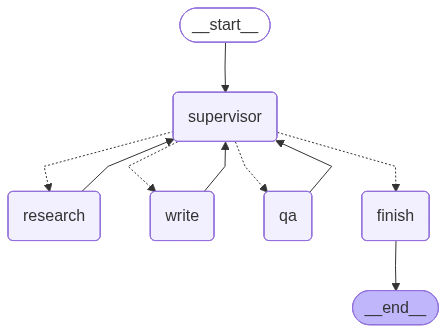

In [17]:
from IPython.display import Image, display

# This generates the image data
graph_image = graph.get_graph().draw_mermaid_png()

# This displays it in your notebook
display(Image(graph_image))

## 13) Run the first request

The agent should go through research, writing, and QA before producing the final brief.


In [18]:
config = {'configurable': {'thread_id': 'policy-brief-1'}}

result = graph.invoke(
    {
        'messages': [],
        'question': 'Create a policy brief on explainable machine learning for public policy.',
        'stage': '',
        'research_notes': '',
        'draft': '',
        'qa_report': '',
        'final_brief': '',
    },
    config=config,
)

result


{'messages': [],
 'question': 'Create a policy brief on explainable machine learning for public policy.',
 'stage': 'finish',
 'research_notes': 'Here are 3 to 5 evidence bullets with page references:\n* Explainable machine learning is highly desired in high-stakes policy decisions, such as those in health, criminal justice, education, and employment, to provide data-driven insights and supplement human expertise (page 0).\n* The field of explainable ML has expanded in recent years, but much of the work has not taken real-world needs into account, and a majority of proposed methods are designed with generic explainability goals (page 0).\n* The use of machine learning in public policy problems can analyze large amounts of data to identify patterns and make predictions about future events, such as the risk of an evicted individual ending up homeless or a student not graduating high school on time (page 2).\n* The effectiveness of generated explanations in helping end-users make better d

## 14) Ask a follow-up in the same thread

The same checkpointed thread can be reused for a revised request.


In [19]:
follow_up = graph.invoke(
    {
        'messages': [],
        'question': 'Now make it shorter and focus on the research gaps.',
        'stage': '',
        'research_notes': '',
        'draft': '',
        'qa_report': '',
        'final_brief': '',
    },
    config=config,
)

follow_up


{'messages': [],
 'question': 'Now make it shorter and focus on the research gaps.',
 'stage': 'finish',
 'research_notes': 'Here are 3 to 5 evidence bullets with page references:\n* Research gaps exist in evaluating the capabilities of existing explainable ML methods in real-world public policy contexts, with a lack of rigorous application-grounded evaluation studies [page 10].\n* There is a need for concerted efforts from machine learning and policy practitioners to conduct well-designed application-grounded evaluation studies to establish the utility of explainable ML methods in public policy domains [page 12].\n* The primary use-cases of ML explanations in public policy applications include policy administration tasks where predictive ML models are used to support human decisions, with goals such as improving efficiency, effectiveness, and equity of outcomes [page 1].\n* Evaluations of explainable ML methods should focus on their ability to improve societal outcomes of interest, ra

## 15) What each agent is responsible for

- Researcher: gather evidence from the PDF
- Writer: turn evidence into a readable brief
- QA: identify unsupported claims and revise for clarity
- Supervisor: decide which subagent runs next

That division matches the LangChain multi-agent pattern where specialized agents are coordinated by a main agent. 


## Key takeaways

This notebook uses a real PDF-backed policy brief workflow and a supervisor graph that coordinates specialized researcher, writer, and QA agents. The design matches LangChain’s multi-agent guidance: a main agent coordinates subagents, centralized control stays in one place, and the system is built around context engineering and specialization. 


## References

- Component architecture: https://docs.langchain.com/oss/python/langchain/component-architecture#multi-agent-system
- Multi-agent patterns: https://docs.langchain.com/oss/python/langchain/multi-agent/index#patterns
- Subagents: https://docs.langchain.com/oss/python/langchain/multi-agent/subagents
